# NIP Project

In [617]:
!pip install brian2
from brian2 import *
start_scope()

## Simulating the bipolar neuron

### Creating the bipolar neuron


In [618]:
length_thin = 200 *um
diameter_thin = 2 *um
compartments_thin = 0.05 * length_thin /um

# Morphology
morpho = Soma(20*um)
morpho.L = Cylinder(diameter=diameter_thin, length=length_thin, n=compartments_thin)
morpho.R = Cylinder(diameter=diameter_thin, length=length_thin, n=compartments_thin)

# Passive channels
gL = 1e-4*siemens/cm**2
EL = -70*mV
Es = 0*mV
eqs='''
Im = gL*(EL-v) : amp/meter**2
Is = (gs_L + gs_R) * (Es-v) : amp (point current)
gs_L : siemens
gs_R : siemens
'''

neuron = SpatialNeuron(
    morphology=morpho,
    model=eqs,
    Cm=1*uF/cm**2,
    Ri=200*ohm*cm,
    method='exponential_euler'
)
neuron.v = EL


### Plotting the Input function simulating sound waves

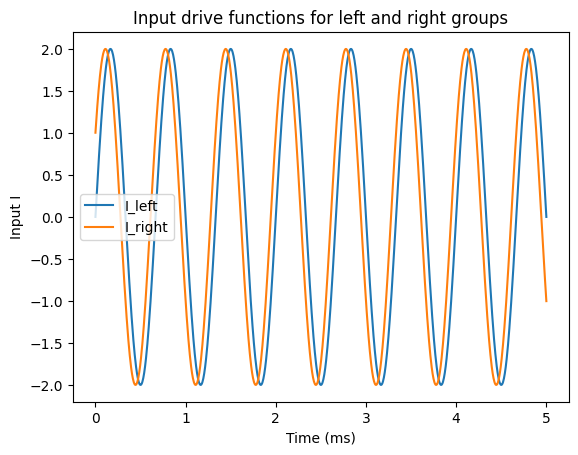

In [619]:
A = 2
f = 1500 # Hz - 1500Hz = 1,5 kHz like in Agmon-Snir
phase_shift_90deg = 0.525   # should be 0.000525

t_ms = np.linspace(0, 5, 1000)  # time i ms for plot
t_sec = t_ms/1000               # time in ms for I

def I(A , f , phase_shift=0):
    # A = amplitude , f = frequency in Hz, phase_shift = phase_shift in s
    return A * sin(2 * pi * f * t_sec + phase_shift)

I_left = I(A, f, 0)
I_right = I(A, f, phase_shift=phase_shift_90deg)

plt.plot(t_ms, I_left, label="I_left")
plt.plot(t_ms, I_right, label="I_right")
plt.xlabel('Time (ms)')
plt.ylabel('Input I')
plt.title('Input drive functions for left and right groups')
plt.legend()
plt.show()

### Parameters for input

In [620]:
A = A #amplitude
f = f*Hz
tau = 1*ms

def eqs(A, f , phase_shift=0):
    # A = amplitude , f = frequency in Hz, phase_shift = phase_shift in s
    eq = '''dx/dt = (I-x)/tau : 1''' + '''\nI = A * sin(2 * pi * f * t + ''' + str(phase_shift) + ''') : 1'''
    print("Equation: \n" + eq)
    return eq

N_left = 6
eqs_left = eqs(A, f , phase_shift=0)

N_right = 6
eqs_right = eqs(A, f , phase_shift=phase_shift_90deg)

Equation: 
dx/dt = (I-x)/tau : 1
I = A * sin(2 * pi * f * t + 0) : 1
Equation: 
dx/dt = (I-x)/tau : 1
I = A * sin(2 * pi * f * t + 0.525) : 1


### creating input neurons

In [621]:
#left ear
v_rest = -70
stimulation_left = NeuronGroup(N_left, eqs_left, threshold='x > -40', reset='x =' + str(v_rest),
                          method='euler')
stimulation_left.x = v_rest

#right ear
stimulation_right = NeuronGroup(N_right, eqs_right, threshold='x> -40', reset='x='+ str(v_rest),
                          method='euler')
stimulation_right.x = v_rest


### Synapses

In [622]:
# Synapses
taus = 1*ms
w = 20*nS

# left dendrite
S_left = Synapses(
        stimulation_left,
        neuron,
        model= '''
           dg/dt = -g/taus : siemens (clock-driven)
           gs_L_post = g : siemens (summed)
        ''',
        on_pre='g += w',
        method='exact')

# right dendrite
S_right = Synapses(
        stimulation_right,
        neuron,
        model= '''
           dg/dt = -g/taus : siemens (clock-driven)
           gs_R_post = g : siemens (summed)
        ''',
        on_pre='g += w',
        method='exact')


# Connect stimulation neurons to last compartment of left dendrite
S_left.connect(i=range(N_left), j=morpho.L[-1])

# Connect stimulation neurons to last compartment of right dendrite
S_right.connect(i=range(N_right), j=morpho.R[-1])

### Monitors

In [623]:
# Monitors
mon_soma = StateMonitor(neuron, 'v', record=[0])
mon_L = StateMonitor(neuron.L, 'v', record=True)
mon_R = StateMonitor(neuron.R, 'v',
                     record=morpho.R[-1])
mon_inp_left = StateMonitor(stimulation_left, 'x', record=0)
mon_inp_right = StateMonitor(stimulation_right, 'x', record=0)

### Simulation

In [624]:
run(5*ms, report='text')

Starting simulation at t=0. s for a duration of 5. ms
5. ms (100%) simulated in < 1s


### Plots

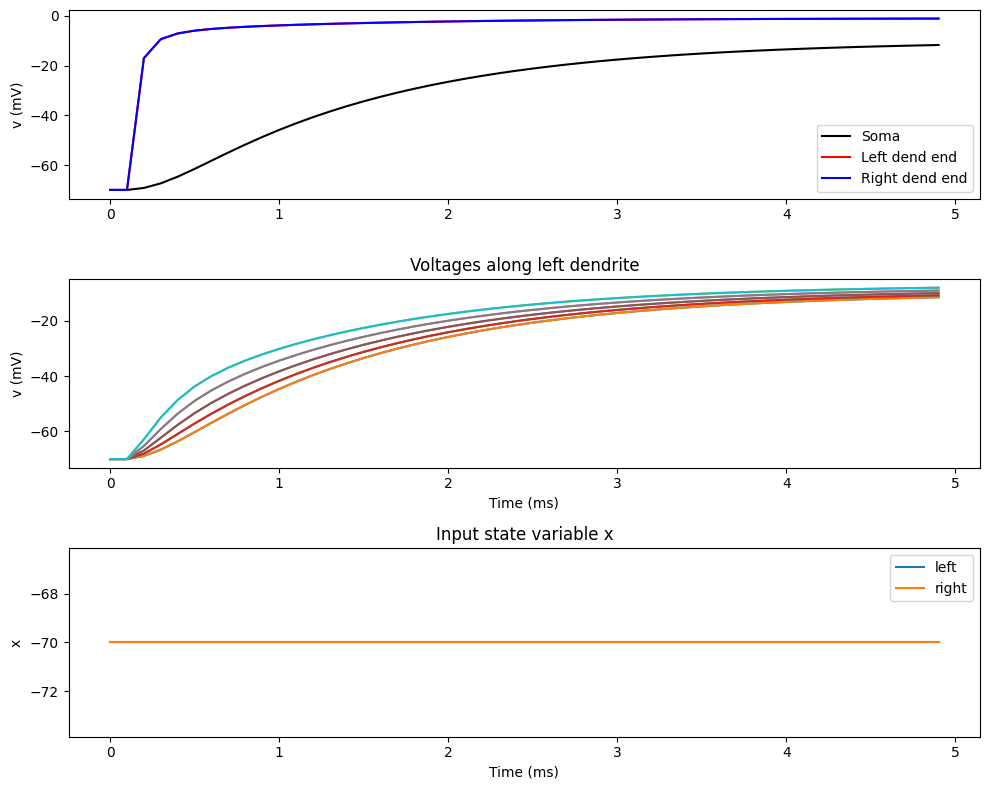

In [625]:
plt.figure(figsize=(10, 8))

# First subplot: soma and dendrite voltage traces
plt.subplot(3, 1, 1)
plt.plot(mon_L.t / ms, mon_soma[0].v / mV, 'k', label='Soma')
plt.plot(mon_L.t / ms, mon_L[morpho.L[-1]].v / mV, 'r', label='Left dend end')
plt.plot(mon_L.t / ms, mon_R[morpho.R[-1]].v / mV, 'b', label='Right dend end')
plt.ylabel('v (mV)')
plt.legend()

# Second subplot: voltage profiles along the left dendrite
plt.subplot(3, 1, 2)
for xi in linspace(0*um, 100*um, 10, endpoint=False):
    plt.plot(mon_L.t / ms, mon_L[morpho.L[xi]].v / mV)
plt.xlabel('Time (ms)')
plt.ylabel('v (mV)')
plt.title('Voltages along left dendrite')

# Third subplot: input neuron variable (use correct monitor and variable)
plt.subplot(3, 1, 3)
plt.plot(mon_inp_left.t / ms, mon_inp_left.x[0], label='left')
#plt.plot(mon_inp_left.t / ms, mon_inp_left.x[1])
#plt.plot(mon_inp_left.t / ms, mon_inp_left.x[2])
plt.plot(mon_inp_right.t / ms, mon_inp_right.x[0], label='right')
plt.xlabel('Time (ms)')
plt.ylabel('x')
plt.title('Input state variable x')
plt.legend()

plt.tight_layout()
plt.show()